## WorldView Full-Scene DEMs vs. 3DEP Lidar: Atlanta and UCSD

The two full-scene benchmarks scored each site's DEMs against ICESat-2:
- [Atlanta](https://asp-plot.readthedocs.io/en/latest/examples/notebooks/worldview_spacenet_atlanta_full_benchmark.html): 21 DEMs from five same-pass WorldView-2 strips.
- [UCSD](https://asp-plot.readthedocs.io/en/latest/examples/notebooks/worldview_spacenet_ucsd_full_benchmark.html): 18 DEMs from five multi-date WorldView-3 scenes.

ICESat-2 is accurate but sparse: 14,000–38,000 shared points on stable terrain along about 100 beam tracks, which barely sample steep ground. This notebook scores the same 39 DEMs against **USGS 3DEP 1 m lidar DEMs**, millions of cells per DEM. It asks:
- Does a dense reference agree with ICESat-2 on the ranking and on the effect sizes?
- What does it show where ICESat-2 is thin: steep slopes at UCSD, and along-track patterns at Atlanta?

The lidar tiles were found with the [uw-cryo/stac-3dep-1m](https://github.com/uw-cryo/stac-3dep-1m) STAC catalog:

| site | 3DEP project | lidar flown | imagery | gap |
|---|---|---|---|---|
| UCSD | `San_Diego_CA_2014_LiDAR` (QL2) | 2014-10-27 to 2015-02-17 | 2014-11-09 to 2015-02-12 | **none**: same weeks |
| Atlanta | `GA_Statewide_2018_B18_DRRA`, with gaps filled by `GA_Central_2019_B19` | 2018-11-27 to 2020-06-14 | 2009-12-22 | 9–10 years |

**Method.**
- **Bare earth only.** The 3DEP 1 m products are bare-earth terrain models, and stereo makes surface models. So they are compared only on **open ground**: ESA WorldCover 2021 shrub, grass, crop, bare, wetland and moss. Trees, built-up and water are excluded.
- **Datum.** The lidar was converted from NAVD88 to ellipsoid heights with NOAA GEOID12B (or GEOID18 for the 2019 project).
- **Common frame.** The lidar was aligned with `pc_align` to the same ICESat-2 points on open ground, so the lidar and the ICESat-2-aligned DEMs share one frame.
- **Common grid.** Every DEM's aligned copy and the lidar (averaged from 1 m) are resampled to one grid per site, at the DEMs' posting: 1.9 m Atlanta, 1.2 m UCSD.
- **Residuals.** dh = DEM − lidar. Per DEM there is a 30-NMAD gross cut, then 3σ, as in `DEMBenchmark`.
- **Ranking.** DEMs are ranked on the **shared** open-ground cells, those valid in every DEM of the site.
- **Separability.** It uses the same paired block bootstrap as the benchmarks, on a 20 m lattice of those cells with 1 km blocks. Nearby cells are correlated, so the blocks, not the cell count, set the interval widths.

The rasters were processed on a compute node by `scripts/lidar/02_prep_lidar.py` and `03_compare.py` (in the repo's untracked `scripts/` folder). This notebook reads their tables and maps.

In [1]:
import glob, os, re
import numpy as np, pandas as pd, rasterio as rio
import matplotlib.pyplot as plt
from rasterio.enums import Resampling
from asp_plot.dem_benchmark import DEMBenchmark

SITES = {
    "Atlanta": dict(root="/nobackup/bpurint1/data/atlanta",
                    fb="/nobackup/bpurint1/data/atlanta/WV/20091222_spacenet/full_benchmark"),
    "UCSD": dict(root="/nobackup/bpurint1/data/ucsd",
                 fb="/nobackup/bpurint1/data/ucsd/WV3/core3d/full_benchmark"),
}
for s in SITES.values():
    s["cmp"] = f"{s['root']}/lidar/compare"
    s["stats"] = pd.read_csv(f"{s['cmp']}/stats.csv")
    s["by_slope"] = pd.read_csv(f"{s['cmp']}/by_slope.csv")
    s["by_class"] = pd.read_csv(f"{s['cmp']}/by_class.csv")
    s["along"] = pd.read_csv(f"{s['cmp']}/along_track.csv")

def describe(label):
    """(flow, convergence in degrees or NaN, short name) from a benchmark label folder name."""
    m = re.match(r"(raw_)?pair_(.+)-(.+)_([0-9.]+)$", label)
    if m:
        return ("raw pair" if m[1] else "map pair"), float(m[4]), f"{m[2]}-{m[3]}"
    if label.startswith("MVS"):
        return "multi-view", np.nan, label.replace("MVS_5_", "MVS ")
    return "blend", np.nan, label.replace("_", " ")

def dem_path(fb, label):
    """Original DEM of a label (the cached pc_align run under fb/dem_benchmark/<label>/ is reused)."""
    flow, _, name = describe(label)
    if flow.endswith("pair"):
        a, b = name.split("-")
        d = "raw" if flow == "raw pair" else "map"
        for x, y in ((a, b), (b, a)):
            fn = f"{fb}/{d}/stereo_pair_{x}_{y}/run-DEM.tif"
            if os.path.exists(fn):
                return fn
    if flow == "multi-view":
        ref = label.split("ref_")[1]  # Atlanta "nadir10" -> ref10, UCSD "n08" -> ref_n08
        return f"{fb}/map/stereo_mvs5_" + (f"ref{ref[5:]}" if ref.startswith("nadir") else f"ref_{ref}") + "/run-DEM.tif"
    n = label.split("_")[0]
    wide = "_15_" in label
    med = "median" in label
    stem = f"pairwise_wide{n}" if wide else f"pairwise{n}"
    return f"{fb}/map/{stem}{'_median' if med else ''}_mosaic-DEM.tif"

for name, s in SITES.items():
    s["stats"][["flow", "conv", "short"]] = s["stats"]["label"].apply(lambda l: pd.Series(describe(l)))
    s["stats"]["name"] = np.where(s["stats"].flow == "raw pair", "raw " + s["stats"].short, s["stats"].short)
    missing = [l for l in s["stats"]["label"] if not os.path.exists(dem_path(s["fb"], l))]
    print(name, len(s["stats"]), "DEMs; missing originals:", missing)

Atlanta 21 DEMs; missing originals: []
UCSD 18 DEMs; missing originals: []


### The lidar, and how well it agrees with ICESat-2

The lidar itself was aligned to ICESat-2 on open ground. The NMAD below is the lidar's own disagreement with ICESat-2, a floor for every DEM score that follows. At Atlanta it includes up to 7 years of ICESat-2 time after a 2018–2020 survey.

In [2]:
rows = []
for name, s in SITES.items():
    a = pd.read_csv(f"{s['root']}/lidar/align/dem_benchmark.csv") if os.path.exists(f"{s['root']}/lidar/align/dem_benchmark.csv") \
        else pd.read_csv(f"{s['root']}/lidar/align/lidar_vs_icesat2.csv")
    r = a.iloc[0]
    rows.append({"site": name, "ICESat-2 points (open ground)": int(r.n_points),
                 "shift |t| (m)": r.translation_m, "east / north / down (m)": f"{r.east_shift_m:+.2f} / {r.north_shift_m:+.2f} / {r.down_shift_m:+.2f}",
                 "median after (m)": r.dh_aligned_median_m, "NMAD after (m)": r.dh_aligned_nmad_m})
pd.DataFrame(rows).set_index("site").round(2)

,ICESat-2 points (open ground),shift |t| (m),east / north / down (m),median after (m),NMAD after (m)
site,,,,,
Atlanta,16847,1.29,-0.33 / +0.07 / -1.24,-0.02,0.36
UCSD,6086,0.76,+0.56 / +0.14 / -0.49,-0.15,0.45


Both shifts are mostly vertical: about −1.2 m at Atlanta, the expected offset between NAD83(2011) and the ITRF-based frame of WGS84 and ICESat-2. The residual NMADs (0.36 m Atlanta, 0.45 m UCSD) include ICESat-2's own noise. They also include the land-cover mask's errors: WorldCover is from 2021, and an "open ground" cell can hold a shrub or a parked car.

Below are the lidar and the open-ground cells used, per site.

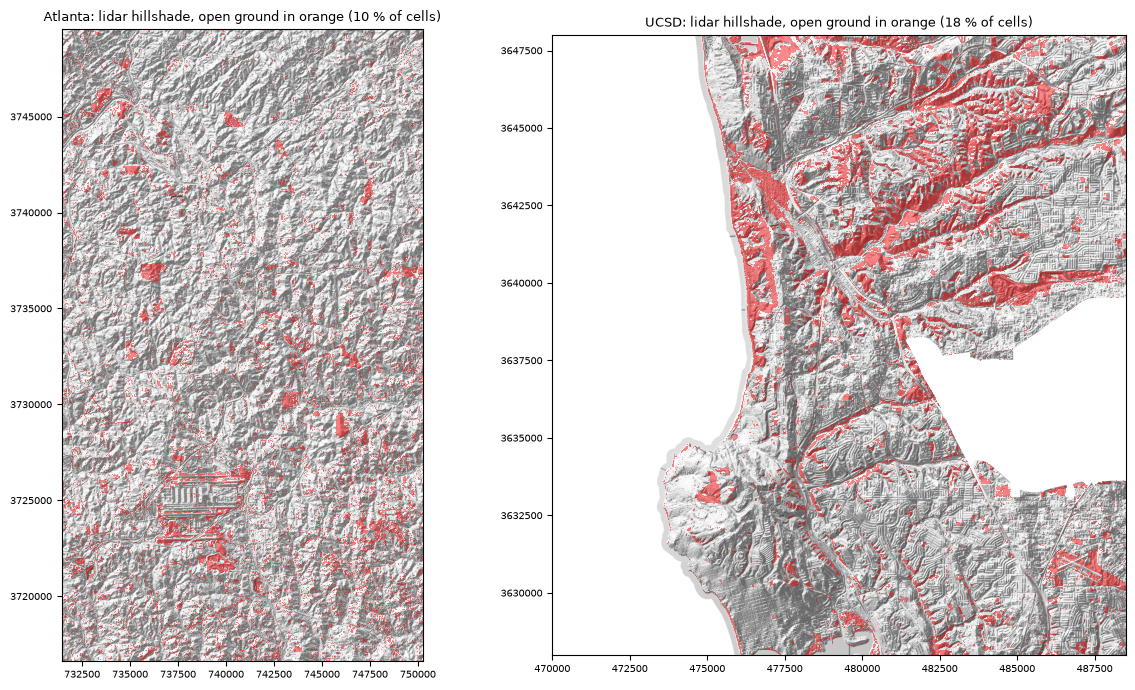

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(12, 7))
for ax, (name, s) in zip(axs, SITES.items()):
    g = f"{s['root']}/lidar/grid"
    with rio.open(f"{g}/lidar.tif") as ds:
        f = 8
        z = ds.read(1, out_shape=(ds.height // f, ds.width // f), resampling=Resampling.average, masked=True)
        ext = [ds.bounds.left, ds.bounds.right, ds.bounds.bottom, ds.bounds.top]
    with rio.open(f"{g}/worldcover.tif") as ds:
        wc = ds.read(1, out_shape=(ds.height // f, ds.width // f), resampling=Resampling.nearest)
    dx, dy = np.gradient(z.filled(np.nan), 8 * 1.9 if name == "Atlanta" else 8 * 1.2)
    hs = np.cos(np.arctan(np.hypot(dx, dy))) * 0.7 + 0.3 * np.cos(np.arctan2(dy, dx) - np.pi / 4)
    ax.imshow(hs, cmap="gray", extent=ext)
    og = np.isin(wc, [20, 30, 40, 60, 90, 100]) & ~z.mask
    ax.imshow(np.where(og, 1.0, np.nan), cmap="autumn", alpha=0.45, extent=ext, interpolation="nearest")
    ax.set_title(f"{name}: lidar hillshade, open ground in orange ({100 * og.sum() / (~z.mask).sum():.0f} % of cells)", fontsize=9)
    ax.ticklabel_format(style="plain"); ax.tick_params(labelsize=7)
plt.tight_layout()

### Rankings: lidar vs. ICESat-2

Each DEM is scored twice:
- **ICESat-2:** re-scored here from the cached `pc_align` runs with the benchmarks' settings (stable terrain, shared points), so the numbers are those of the two benchmark notebooks.
- **Lidar:** NMAD on the shared open-ground cells.

`lidar vs best` is the paired bootstrap 95 % interval on the DEM's lidar NMAD minus the best DEM's. An interval that includes 0 means the DEM is not separable from the best.

In [4]:
def icesat2_scores(name, s):
    labels = list(s["stats"]["label"])
    bench = DEMBenchmark(s["fb"], {l: dem_path(s["fb"], l) for l in labels},
                         parquet=f"{s['fb']}/atl06sr_all.parquet", filter_out=["water", "trees"],
                         n_bootstrap=0)
    bench.run(pc_align=True)
    return bench.stats_df.set_index("label")["dh_aligned_shared_nmad_m"], int(bench.stats_df["n_shared"].iloc[0])

import contextlib, io
for name, s in SITES.items():
    with contextlib.redirect_stdout(io.StringIO()):
        nm, n = icesat2_scores(name, s)
    s["stats"]["is2_nmad"] = s["stats"]["label"].map(nm)
    s["n_is2"] = n

def table(s):
    t = s["stats"].copy()
    t["lidar rank"] = t["shared_nmad"].rank().astype(int)
    t["ICESat-2 rank"] = t["is2_nmad"].rank().astype(int)
    t["lidar vs best (m)"] = [f"[{a:+.2f}, {b:+.2f}]" for a, b in zip(t.nmad_vs_best_ci_lo, t.nmad_vs_best_ci_hi)]
    return t[["name", "flow", "conv", "is2_nmad", "shared_nmad", "shared_median", "lidar vs best (m)", "p_best",
              "coverage_pct", "ICESat-2 rank", "lidar rank"]].rename(columns={
        "name": "DEM", "conv": "conv (°)", "is2_nmad": "ICESat-2 NMAD (m)", "shared_nmad": "lidar NMAD (m)",
        "shared_median": "lidar median (m)", "coverage_pct": "open-ground coverage (%)"}).round(2)

s = SITES["Atlanta"]
print(f"Atlanta: {s['stats'].shared_n.iloc[0]:,} shared open-ground cells "
      f"({s['stats'].shared_n.iloc[0] * 1.9**2 / 1e6:.1f} km²); {s['n_is2']:,} shared ICESat-2 points")
table(s)

Atlanta: 10,745,713 shared open-ground cells (38.8 km²); 38,305 shared ICESat-2 points


,DEM,flow,conv (°),ICESat-2 NMAD (m),lidar NMAD (m),lidar median (m),lidar vs best (m),p_best,open-ground coverage (%),ICESat-2 rank,lidar rank
0,raw 10-21,raw pair,31.7,0.76,0.60,0.12,"[+0.00, +0.00]",1.0,78.22,1,1
1,raw 13-10,raw pair,21.8,0.78,0.62,0.11,"[+0.01, +0.04]",0.0,84.81,3,2
2,raw 8-21,raw pair,27.0,0.78,0.63,0.16,"[+0.02, +0.04]",0.0,82.79,2,3
3,MVS ref_nadir10,multi-view,NaN,0.87,0.73,0.06,"[+0.11, +0.14]",0.0,87.75,5,4
4,6 pairs 15 mosaic,blend,NaN,0.86,0.73,0.08,"[+0.10, +0.14]",0.0,93.88,4,5
5,10-16,map pair,26.3,0.88,0.74,0.07,"[+0.12, +0.16]",0.0,80.16,8,6
6,13-10,map pair,21.8,0.89,0.75,0.06,"[+0.12, +0.16]",0.0,86.88,9,7
7,10 pairs median mosaic,blend,NaN,0.87,0.75,0.10,"[+0.13, +0.16]",0.0,98.15,6,8
8,MVS ref_nadir13,multi-view,NaN,0.88,0.75,0.08,"[+0.13, +0.17]",0.0,87.88,7,9
9,10-21,map pair,31.7,0.90,0.76,0.09,"[+0.14, +0.18]",0.0,79.94,10,10


In [5]:
s = SITES["UCSD"]
print(f"UCSD: {s['stats'].shared_n.iloc[0]:,} shared open-ground cells "
      f"({s['stats'].shared_n.iloc[0] * 1.2**2 / 1e6:.1f} km²); {s['n_is2']:,} shared ICESat-2 points")
table(s)

UCSD: 12,276,051 shared open-ground cells (17.7 km²); 14,237 shared ICESat-2 points


,DEM,flow,conv (°),ICESat-2 NMAD (m),lidar NMAD (m),lidar median (m),lidar vs best (m),p_best,open-ground coverage (%),ICESat-2 rank,lidar rank
0,n15-n24,map pair,17.5,1.11,0.78,-0.22,"[+0.00, +0.00]",0.73,88.47,7,1
1,10 pairs mosaic,blend,NaN,1.03,0.80,-0.18,"[-0.02, +0.05]",0.22,98.14,1,2
2,nadir-n15,map pair,15.1,1.13,0.83,-0.73,"[-0.01, +0.10]",0.04,89.79,9,3
3,n24-n08,map pair,34.0,1.11,0.90,0.08,"[+0.06, +0.16]",0.00,83.76,8,4
4,10 pairs median mosaic,blend,NaN,1.07,0.91,-0.30,"[+0.08, +0.16]",0.00,98.16,3,5
5,n24-n16,map pair,25.3,1.06,0.95,0.11,"[+0.12, +0.20]",0.00,88.76,2,6
6,nadir-n16,map pair,16.8,1.10,0.96,-0.33,"[+0.12, +0.24]",0.00,86.05,6,7
7,nadir-n24,map pair,26.0,1.16,0.98,-0.03,"[+0.15, +0.23]",0.00,86.01,13,8
8,n16-n08,map pair,17.1,1.18,1.00,-0.30,"[+0.17, +0.27]",0.00,91.00,14,9
9,MVS ref_n08,multi-view,NaN,1.09,1.11,-0.31,"[+0.27, +0.39]",0.00,91.32,5,10


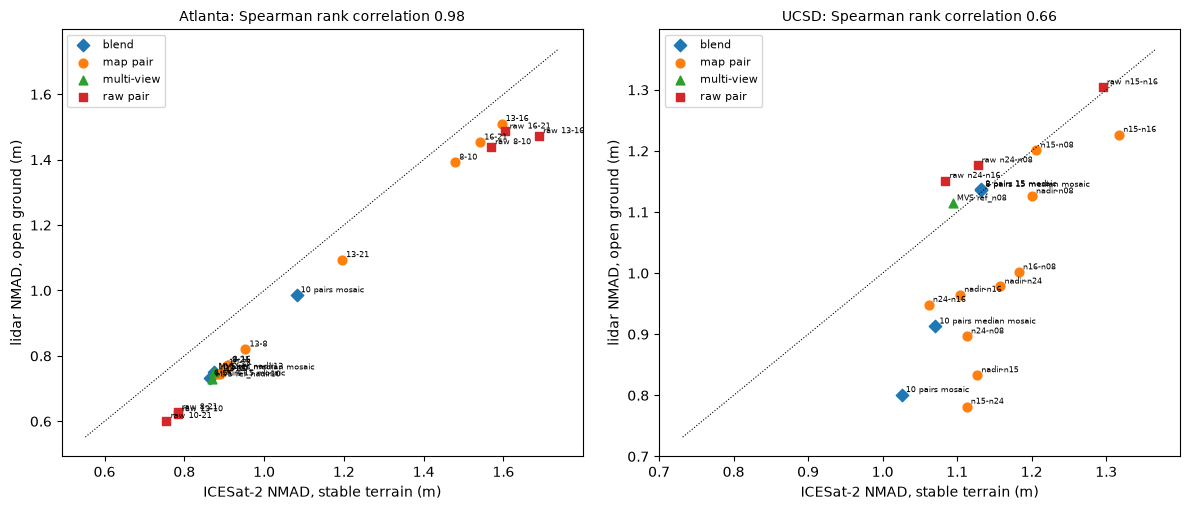

In [6]:
from scipy.stats import spearmanr
fig, axs = plt.subplots(1, 2, figsize=(12, 5.2))
mk = {"map pair": "o", "raw pair": "s", "multi-view": "^", "blend": "D"}
for ax, (name, s) in zip(axs, SITES.items()):
    t = s["stats"]
    for flow, g in t.groupby("flow"):
        ax.scatter(g.is2_nmad, g.shared_nmad, marker=mk[flow], label=flow, s=40)
        for _, r in g.iterrows():
            ax.annotate(r["name"], (r.is2_nmad, r.shared_nmad), fontsize=6, xytext=(3, 2), textcoords="offset points")
    lo, hi = min(t.is2_nmad.min(), t.shared_nmad.min()) - 0.05, max(t.is2_nmad.max(), t.shared_nmad.max()) + 0.05
    ax.plot([lo, hi], [lo, hi], "k:", lw=0.8)
    rho = spearmanr(t.is2_nmad, t.shared_nmad).statistic
    ax.set_title(f"{name}: Spearman rank correlation {rho:.2f}", fontsize=10)
    ax.set_xlabel("ICESat-2 NMAD, stable terrain (m)"); ax.set_ylabel("lidar NMAD, open ground (m)")
    ax.legend(fontsize=8)
plt.tight_layout()

### Convergence angle

Pair NMAD against convergence angle, lidar (filled) and ICESat-2 (hollow). Blends and multi-view runs are the horizontal lines.

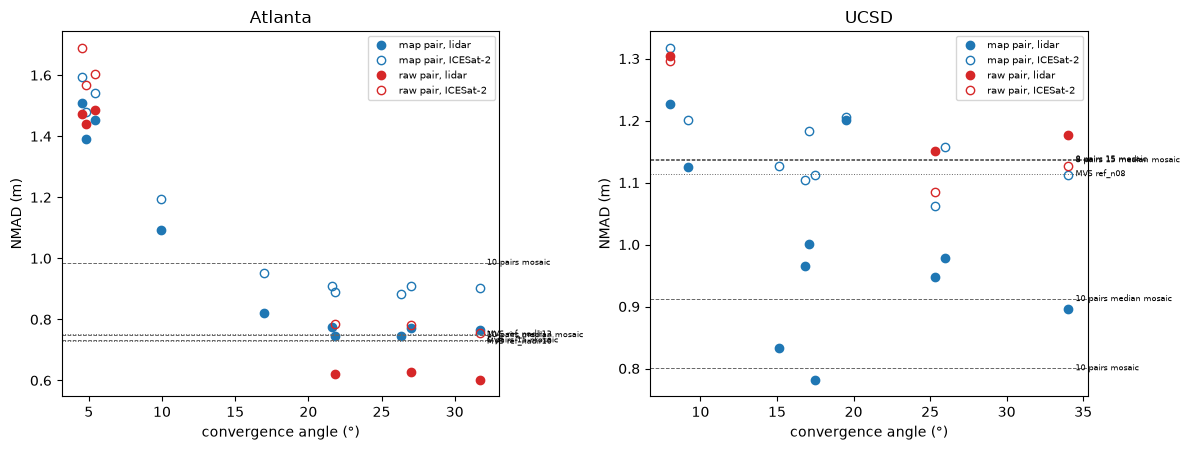

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.6), sharey=False)
for ax, (name, s) in zip(axs, SITES.items()):
    t = s["stats"]
    for flow, c in (("map pair", "C0"), ("raw pair", "C3")):
        g = t[t.flow == flow].sort_values("conv")
        ax.plot(g.conv, g.shared_nmad, "o", c=c, label=f"{flow}, lidar")
        ax.plot(g.conv, g.is2_nmad, "o", mfc="none", c=c, label=f"{flow}, ICESat-2")
    for _, r in t[t.flow.isin(["blend", "multi-view"])].iterrows():
        ax.axhline(r.shared_nmad, lw=0.7, ls="--" if r.flow == "blend" else ":", c="0.4")
        ax.text(t.conv.max() + 0.5, r.shared_nmad, r.short, fontsize=6, va="center")
    ax.set_title(name); ax.set_xlabel("convergence angle (°)"); ax.set_ylabel("NMAD (m)"); ax.legend(fontsize=7)
plt.tight_layout()

### Slope: where the dense reference adds most

ICESat-2 barely samples steep open ground, and the lidar covers all of it. Below is NMAD by lidar slope on the shared open-ground cells, for every pair. Next comes the raw − mapprojected difference for the pairs run both ways.

raw − map lidar NMAD (m) by slope class; negative = raw better


0-5  5-10  10-20  20-30  30-90
site    pair                                    
Atlanta 10-21   -0.16 -0.13  -0.11  -0.05  -0.05
        13-10   -0.12 -0.11  -0.11  -0.07  -0.02
        13-16   -0.05 -0.00  -0.02  -0.04   0.15
        16-21    0.03  0.04   0.04   0.01   0.11
        8-10     0.04  0.06   0.09   0.16   0.23
        8-21    -0.15 -0.10  -0.07   0.03  -0.01
UCSD    n15-n16  0.18  0.11   0.02  -0.03  -0.09
        n24-n08  0.13  0.18   0.22   0.39   0.72
        n24-n16  0.09  0.12   0.16   0.22   0.57

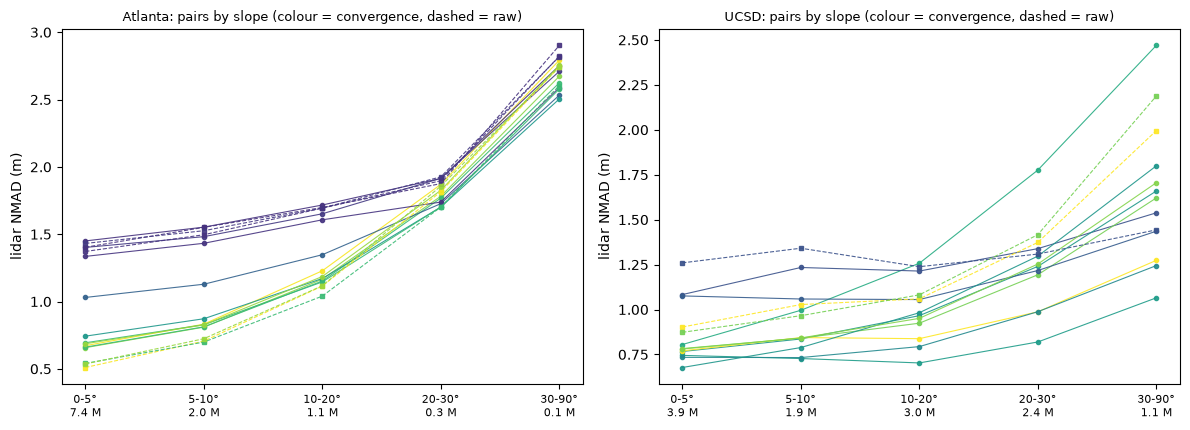

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, (name, s) in zip(axs, SITES.items()):
    bs = s["by_slope"].merge(s["stats"][["label", "flow", "short", "conv"]], on="label")
    order = ["0-5", "5-10", "10-20", "20-30", "30-90"]
    bs["x"] = bs.slope.map({k: i for i, k in enumerate(order)})
    bs = bs.sort_values("x")
    for (lab, flow), g in bs[bs.flow.str.endswith("pair")].groupby(["label", "flow"]):
        ax.plot(g.x, g.nmad, "-o" if flow == "map pair" else "--s", ms=3, lw=0.8,
                c=plt.cm.viridis(min(g.conv.iloc[0], 32) / 32), alpha=0.9)
    n = bs.groupby("slope").n.first().reindex(order)
    ax.set_xticks(range(len(n))); ax.set_xticklabels([f"{k}°\n{v / 1e6:.1f} M" for k, v in n.items()], fontsize=8)
    ax.set_title(f"{name}: pairs by slope (colour = convergence, dashed = raw)", fontsize=9); ax.set_ylabel("lidar NMAD (m)")
plt.tight_layout()

rows = []
for name, s in SITES.items():
    bs = s["by_slope"].merge(s["stats"][["label", "flow", "short"]], on="label")
    raw = bs[bs.flow == "raw pair"]
    for short in raw.short.unique():
        a, b = short.split("-")
        m = bs[(bs.flow == "map pair") & bs.short.isin([f"{a}-{b}", f"{b}-{a}"])]
        r = raw[raw.short == short]
        if m.empty:
            continue
        d = r.set_index("slope").nmad - m.set_index("slope").nmad
        rows.append({"site": name, "pair": short, **d.round(2).to_dict()})
print("raw − map lidar NMAD (m) by slope class; negative = raw better")
pd.DataFrame(rows).set_index(["site", "pair"])

### Land cover

NMAD per open-ground class, then the DSM − DTM median on trees and built-up cells. The second is not an error: it is how far the stereo surface sits above bare earth, shown for context.

In [9]:
for name, s in SITES.items():
    bc = s["by_class"].merge(s["stats"][["label", "name", "flow"]], on="label")
    best = s["stats"].sort_values("shared_nmad")["name"].iloc[:4].tolist()
    piv = bc[bc["name"].isin(best)].pivot(index="name", columns="class", values="nmad")
    piv = piv[[c for c in ["grass", "shrub", "crop", "bare", "wetland"] if c in piv]]
    ctx = bc[bc["name"].isin(best)].pivot(index="name", columns="class", values="median")[["trees", "built-up"]]
    cnt = bc[bc["name"] == best[0]].set_index("class").n
    print(f"{name}: cells per class ({best[0]}):", ", ".join(f"{k} {v / 1e6:.1f} M" for k, v in cnt.items() if v > 0))
    display(pd.concat({"NMAD on open ground (m)": piv, "median DSM − DTM (m)": ctx}, axis=1).loc[best].round(2))

Atlanta: cells per class (raw 10-21): grass 10.1 M, crop 0.2 M, bare 1.3 M, trees 57.4 M, built-up 34.5 M


NMAD on open ground (m)                            \
class                             grass shrub  crop  bare wetland   
name                                                                
raw 10-21                          0.61   NaN  0.90  0.72     NaN   
raw 13-10                          0.62   NaN  0.91  0.78    0.11   
raw 8-21                           0.67   NaN  0.95  0.83     NaN   
MVS ref_nadir10                    0.76   NaN  1.37  0.92    0.15   

                median DSM − DTM (m)           
class                          trees built-up  
name                                           
raw 10-21                       0.98     0.35  
raw 13-10                       1.37     0.40  
raw 8-21                        1.17     0.42  
MVS ref_nadir10                 2.55     0.48

UCSD: cells per class (n15-n24): shrub 6.5 M, grass 8.6 M, crop 0.0 M, bare 1.3 M, wetland 0.3 M, trees 25.0 M, built-up 50.1 M


NMAD on open ground (m)                            \
class                             grass shrub  crop  bare wetland   
name                                                                
n15-n24                            0.99  0.84  0.96  1.15    0.37   
10 pairs mosaic                    1.07  0.90  1.02  1.24    0.41   
nadir-n15                          1.07  0.93  1.03  1.30    0.55   
n24-n08                            1.05  1.01  1.13  1.21    0.38   

                median DSM − DTM (m)           
class                          trees built-up  
name                                           
n15-n24                         1.26     0.48  
10 pairs mosaic                 1.12     0.48  
nadir-n15                       0.93     0.38  
n24-n08                         1.92     0.87

### Difference maps

Block medians (16 × 16 cells, about 30 m at Atlanta and 19 m at UCSD) of DEM − lidar on open ground, for each site's best DEM, a narrow pair and a blend. Blank areas are trees, buildings, water, or outside the DEM.

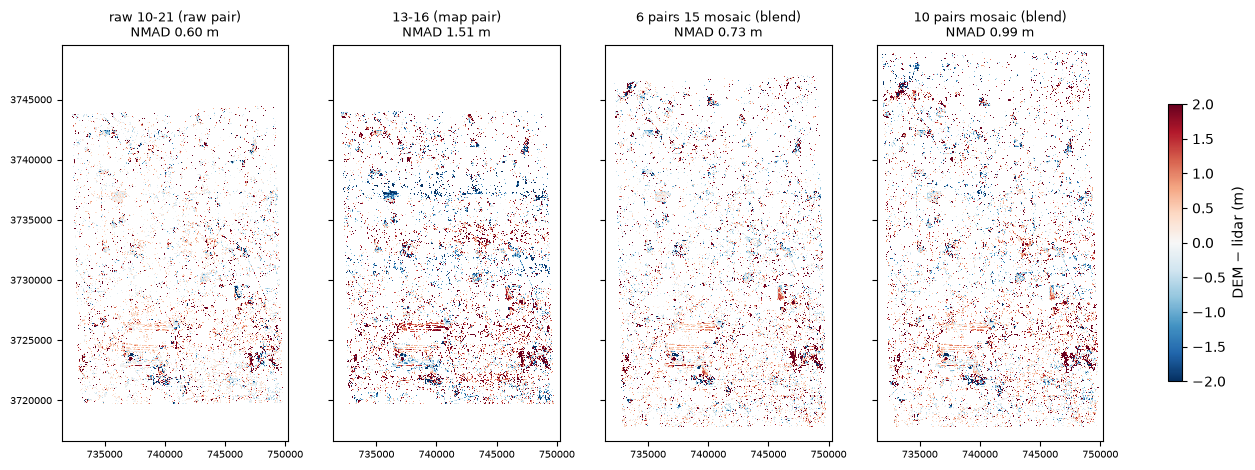

In [10]:
def show_maps(name, picks):
    s = SITES[name]
    fig, axs = plt.subplots(1, len(picks), figsize=(4.2 * len(picks), 6), sharey=True)
    for ax, lab in zip(axs, picks):
        with rio.open(f"{s['cmp']}/maps/{lab}.tif") as ds:
            a = ds.read(1); b = ds.bounds
        im = ax.imshow(a, cmap="RdBu_r", vmin=-2, vmax=2, extent=[b.left, b.right, b.bottom, b.top], interpolation="nearest")
        r = s["stats"].set_index("label").loc[lab]
        ax.set_title(f"{r['name']} ({r.flow})\nNMAD {r.shared_nmad:.2f} m", fontsize=9)
        ax.ticklabel_format(style="plain"); ax.tick_params(labelsize=7)
    fig.colorbar(im, ax=axs, shrink=0.6, label="DEM − lidar (m)")

t = SITES["Atlanta"]["stats"].sort_values("shared_nmad")
show_maps("Atlanta", [t.label.iloc[0], "pair_13-16_4.5", "6_pairs_15_mosaic", "10_pairs_mosaic"])

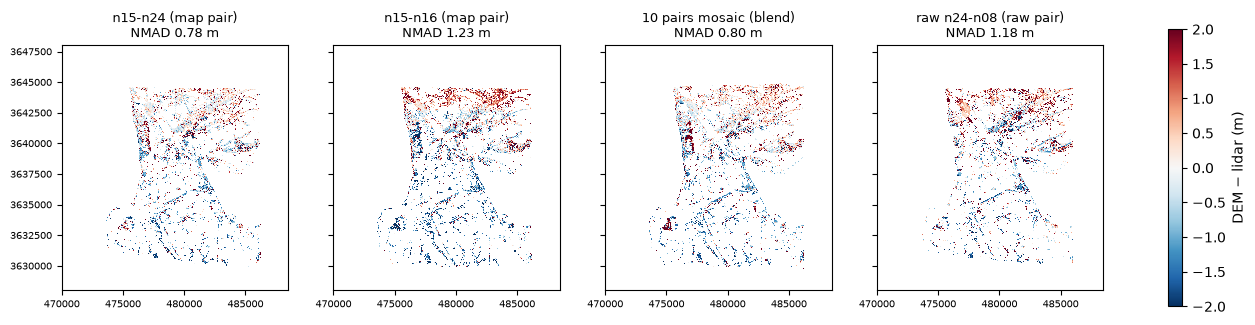

In [11]:
t = SITES["UCSD"]["stats"].sort_values("shared_nmad")
show_maps("UCSD", [t.label.iloc[0], "pair_n15-n16_8.0", "10_pairs_mosaic", "raw_pair_n24-n08_34.0"])

### Along-track pattern at Atlanta

The Atlanta strips run north–south, so northing is the along-track direction. The Atlanta benchmark's ICESat-2 residuals in 1 km bins showed a ±0.3 m along-track wave shared by every DEM. Below are lidar medians in 250 m bins of northing on the shared open ground. A wave shared by every DEM points to the images or the reference. Waves that differ between pairs point to per-scene attitude jitter, the subject of the Atlanta jitter experiment.

std of 250 m bin medians after removing a 2.25 km running median (m):
label
MVS_5_ref_nadir10         0.090
pair_10-21_31.7           0.093
raw_pair_10-21_31.7       0.100
MVS_5_ref_nadir13         0.101
10_pairs_median_mosaic    0.101
6_pairs_15_mosaic         0.103
pair_13-10_21.8           0.104
pair_10-16_26.3           0.108
raw_pair_13-10_21.8       0.109
pair_8-21_27.0            0.117
raw_pair_8-21_27.0        0.134
pair_8-16_21.6            0.136
pair_13-8_17.0            0.150
10_pairs_mosaic           0.179
pair_13-21_9.9            0.219
raw_pair_8-10_4.8         0.435
raw_pair_13-16_4.5        0.442
pair_16-21_5.4            0.443
pair_13-16_4.5            0.450
pair_8-10_4.8             0.491
raw_pair_16-21_5.4        0.499


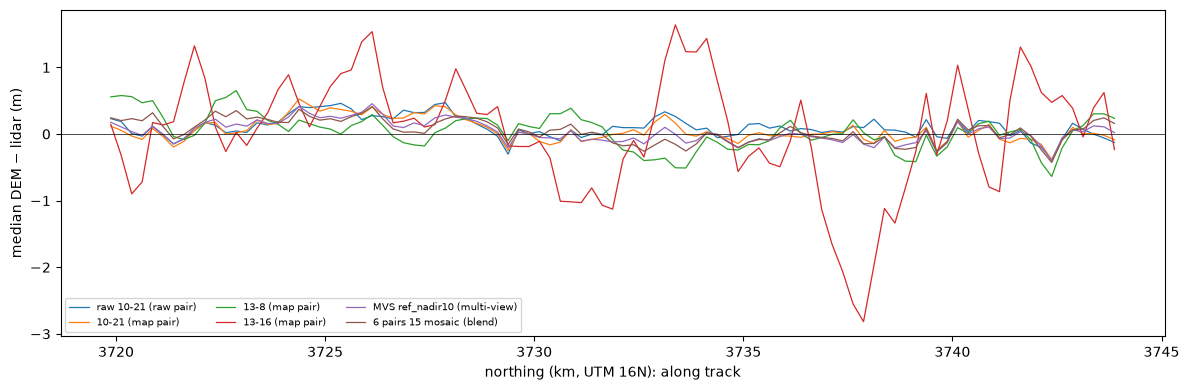

In [12]:
al = SITES["Atlanta"]["along"].merge(SITES["Atlanta"]["stats"][["label", "name", "flow"]], on="label")
picks = ["raw_pair_10-21_31.7", "pair_10-21_31.7", "pair_13-8_17.0", "pair_13-16_4.5", "MVS_5_ref_nadir10", "6_pairs_15_mosaic"]
fig, ax = plt.subplots(figsize=(12, 4))
for lab in picks:
    g = al[(al.label == lab) & (al.n > 2000)]
    r = g.iloc[0]
    ax.plot(g.northing / 1e3, g["median"], lw=0.9, label=f"{r['name']} ({r.flow})")
ax.axhline(0, c="k", lw=0.5); ax.set_xlabel("northing (km, UTM 16N): along track"); ax.set_ylabel("median DEM − lidar (m)")
ax.legend(fontsize=7, ncol=3); plt.tight_layout()
w = al[al.n > 2000].pivot(index="northing", columns="label", values="median")
hp = w - w.rolling(9, center=True, min_periods=3).median()
print("std of 250 m bin medians after removing a 2.25 km running median (m):")
print(hp.std().sort_values().round(3).to_string())

### Key takeaways

The 39 full-scene DEMs were scored on 3DEP lidar over open ground: 10.7 M shared cells (39 km²) at Atlanta and 12.3 M (18 km²) at UCSD.

1. **At Atlanta, the lidar confirms the ICESat-2 benchmark almost exactly** (Spearman 0.98).
    - Raw wide pairs are best (0.60–0.63 m).
    - The 6-pair >15° blend, the median blend and multi-view follow (0.73–0.75 m).
    - The plain 10-pair average is 0.99 m and the 4.5–5.4° pairs 1.39–1.51 m.
    - Raw beats mapprojected on the wide pairs by 0.11–0.16 m on gentle ground (less on steep slopes), as with ICESat-2.

    Lidar NMADs run 0.1–0.15 m below ICESat-2's, because the reference is denser and more precise and the surface is open ground only. The ordering is unchanged. The 9–10 year gap to the lidar does not show up in the ranking.
2. **At UCSD, where the lidar was flown the same weeks as the imagery, the dense reference reorders the middle of the table** (Spearman 0.66).
    - **The multi-date rule holds.** The 10-pair average (0.80 m) stays in the top group, inseparable from the best single pairs n15-n24 (0.78 m) and nadir-n15 (0.83 m).
    - Dropping the two narrow pairs still costs a lot: the 8-pair >15° blends score 1.14 m.
    - The joint multi-view run again trails (1.11 m).
3. **Mapprojection does help on steep terrain. ICESat-2 just could not see it.**
    - At UCSD, raw stereo is 0.20–0.28 m worse than mapprojected for the two wide pairs on the lidar (ICESat-2: a tie).
    - The gap grows with slope: +0.09 to +0.13 m on 0–5° ground, +0.57 to +0.72 m above 30°.
    - The lidar has 3.5 M shared open-ground cells steeper than 20° (the shrub- and grass-covered canyon walls); the ICESat-2 stable-terrain sample has about 450 points there.
4. **Along-track ripples at Atlanta grow as the base shrinks.** The short-scale variation in 250 m bins is about 0.1 m for wide pairs, 0.15 m at 17°, and 0.44–0.50 m for the 4.5–5.4° pairs. This is the height signature of attitude jitter. See the [Atlanta jitter notebook](https://asp-plot.readthedocs.io/en/latest/examples/notebooks/worldview_spacenet_atlanta_jitter.html), where solving for it removes 0.15–0.19 m of NMAD from the narrow pairs.
5. **Per-DEM vertical offsets at UCSD are not negligible.** After each DEM's own ICESat-2 alignment, its median against the lidar ranges from −0.73 to +0.65 m. ICESat-2 alignment over sparse, mostly gentle points leaves decimeter-level offsets on steep, multi-date ground. NMAD ignores them, but a user differencing DEMs would not.

**Caveats.**
- Only open ground is compared (10 % of Atlanta's lidar cells, 18 % of UCSD's), because the lidar is bare earth. Built-up ground, much of both scenes, is not scored here. A first-return lidar surface model would allow it.
- WorldCover is from 2021, so some "open ground" cells held something else on the image dates.
- Atlanta's lidar is 9–10 years after its imagery.